# Tutorial: Classifier Performance via Closure Test
> Harrison B. Prosper<br>
> Created: Sep 15 2025<br>

## Introduction
In the notebook `tutorial_2D_binary_classifier`, we built a simple classifier that approximated the **discriminant**, 
$$f_\widehat{\omega}(x) \approx D(x) = \frac{p(x|1)}{p(x|1) + p(x|0)},$$ 
to classify the points $x \in \mathbb{R}^2$ sampled from a Gaussian mixture density. In notebook `tutorial_ROC_AUC`, the quality of the classifier was evaluated using the **Receiver Operating Characteristic** (ROC) curve and the **Area Under the (ROC) Curve** (AUC). In this notebook, we'll look at another way to assess the performance of the classifier.

## Point clouds and closure tests
**Notation**
\begin{align}
    p_1(x) & \equiv p(x \mid 1), & \quad\text{density of points in class labeled $y = 1$},\\
    p_0(x) & \equiv p(x \mid 0), & \quad\text{density of points in class labeled $y = 0$},\\
    \pi    & \equiv \pi(1),      & \quad\text{prior probability of class labeled $y = 1$},\\
    1 - \pi & \equiv \pi(0),     & \quad\text{prior probability of class labeled $y = 0$}.
\end{align}
Givem the above notation, we can write the probability density of the data as $$m(x) = p_1(x) \, \pi + p_0(x) \,(1 - \pi)$$ and the classifier $C_\pi(x)$, approximated by $f_\widehat{\omega}(x)$, as
$$C_\pi(x) = \frac{p_1(x) \, \pi}{m(x)},$$

with $\pi \equiv \pi(1) = 1/2$. (When there is a possibility of confusion between the number $\pi$ and the prior $\pi$, we'll revert to the notation $\pi(1)$  for the latter.)

Suppose that the prior for the class labeled $y = 1$ is $\pi$, then for a perfect classifier $C_\pi(x)$,
\begin{align}
    C_\pi(x) 
    & = \frac{p_1(x)\, \pi}{p_1(x)\, \pi + p_0(x)\,(1-\pi)},\\
    & = \frac{{\color{blue}D(x)} \, \pi}{{\color{blue} D(x)}\, \pi + (1 - {\color{blue}D(x)})\,(1-\pi)},
\end{align}
where the discriminant $D(x) = C_{\tfrac{1}{2}}(x)$. This shows that training a classifier with a balanced data set ($\pi(1) = 1/2$) is not at all restrictive because we can always map it to a classifier with a prior other than $1/2$.

**Exercise**

From the above, convince yourself that 
\begin{equation}
\bbox[8px, #d1ecf1, border: 1px solid #bee5eb]{\mathbb{E}_{m(x)}[C_\pi] = \pi}.
\end{equation}

Suppose we draw a sample from the density $m(x) =  p_1(x)\, \pi + p_0(x)\,(1-\pi)$, that is, we create a **point cloud** from $m(x)$. Now weight each point by $w(x) = C_\pi(x)$. For a perfect classifier, this procedure yields the function
\begin{align}
    p_w(x) & = w(x) \, m(x), \\
            & = \frac{p_1(x) \, \pi(1)}{m(x)} m(x),\\
            & = p_1(x) \, \pi(1).
\end{align}
This suggests another way to assess the quality of the trained classifier. If the points of class 1 represent some **signal** and those of class 0 represent **background**, that is, noise, weighting the full data set (and admixture of signal and background) recreates the signal.
This notebook builds on this insight. Any procedure that predicts a density that ought to match another, after undergoing some transformation, is called a **closure test**. 

In this in-class assignment you will
  1. Generate some test data.
  2. Generate signal data.
  4. Bin the signal data using a KD-tree (see below) and produce an ordered array of estimated signal probability densities, where the density is given by **bin count / bin volume / total count**.
  5. Using the same KD-tree, bin *all* the test data $x \in X$ weighted by $w(x)$ and produce a second array of estimated probability densities in the same bin order as the first so that a bin-by-bin comparison between the two arrays can be performed.
  6. Visually compare the two arrays of densities using a plot.
  7. Attempt some quantitative statistical test to judge how well the two arrays *fail to* match. 

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

# for reloading previously imported Python modules
import importlib

# for loading serialized Python objects
import joblib

# ML in physics module
import drwho.nn as mlp
import drwho.data as dat
import drwho.kdtree as kdt

# module for shell utilities
import shutil

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": shutil.which('latex') is not None, 
    "font.family": "sans-serif",
    "font.size": FONTSIZE
})

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# file containing parameters of trained gauss2d model
params_file = 'gauss2d_params.pth' 

Available device: cpu 


## Import trained `gauss2d` model

In [3]:
import gauss2d
importlib.reload(gauss2d) # reload gauss2d if this cell is re-executed

model = gauss2d.Gauss2D()
model.load(params_file)   # set model parameters

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
number of parameters 9


## Generate test data point cloud $x \sim m(x)$
Choose a random number seed and generate some test data.
$x$ are the points and $y$ are the targets (or labels).

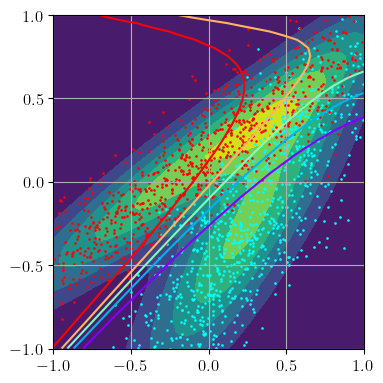

In [4]:
import exactdensity as den
importlib.reload(den)

fexact = den.ExactDensity()

def generate_data(N1, N0, rng):
    # generate data and return as a numpy array
    data = fexact.generate(N1=N1, N0=N0, rng=rng)

    # convert to a dataset
    dataset = dat.Dataset(
        data, start=0, end=len(data), split_col=2, verbose=False)

    # create a loader for the dataset
    loader = dat.DataLoader(
        dataset, batch_size=len(dataset), verbose=False)

    # return all the data
    x, y = next(iter(loader))
    return x, y

# remember to choose a random number seed.
seed = 121121 
rng  = np.random.default_rng(seed)

X, Y = generate_data(100_000, 100_000, rng)

fexact.plot(data=torch.cat([X, Y], dim=1))

## Bin signal data using a KD-tree

Suppose we have $n$ points $\in \mathbb{R}^d$ that we wish to bin. One way to do this is to use a data structure called a KD-tree. The latter can be visualized as a histogram in which the bins (i.e., **leaves**) are constructed by splitting each bin in two, typically, such that each child bin has equal (or near equal) numbers of points. The algorithm is recursive in that the binary partitioning is applied to each of the two child bins of the parent and continues until the number of points in a given bin is $\le$ the desired bin count (`leaf_size`). The bin is then referred to as a **leaf**. The algorithm is called **recursive binary partitioning** and is described informally below.

**Algorithm**
  1. Start with a $d$-dimensional box containing all the points.
  2. Choose a dimension (`axis` in `numpy` jargon) along which to split the bin. (The dimension chosen depends on the depth of the parent bin within the tree.)
  4. If the count in the current bin $\le$ the desired `leaf_size` do not split the bin and call it a `leaf`, otherwise split the bin into two child bins and apply steps 2. and 3. to each child bin.
  5. Continue until all leaves have been constructed.

**Note**: The method `get_leaves()` of the class `KDTree` (in the Python module `kdtree`) returns a list of leaves in *descending order* of estimated probability density.

A `leaf` of a `KDTree` object has the following attributes:
  1. ID: int - leaf identifier (ID = 0 for first leaf, ID = len(leaves)-1 for last leaf)
  1. points: (n, d)-ndarray - points in leaf
  2. bounds: (d, 2)-ndarray - limits of bounding box
  3. volume: float - volume of bounding box
  4. density: float - estimated probability density
  5. indices: array of indices of the points within leaf.

## Generate signal point cloud

In [5]:
# Note: the leaf size (that is, the number of points within leaf) will 
# be exactly equal to the desired leaf size if we choose the number 
# of signal points and the leaf size to be powers of 2.

m = 18
signal_size = 2**m
leaf_size   = 2**(m-6)

# generate points
sig = fexact.rv1.rvs(signal_size, random_state=rng)    
print(f'number of signal points: {len(sig):10d}')

# build the 2D-tree using the "sig" sample
tree = kdt.KDTree(sig, leaf_size=leaf_size, store_nodeinfo=True)

# return the leaves (aka, bins) of the tree
leaves = tree.get_leaves()

print('number of leaves (aka bins):', len(leaves))
print()

print('leaf with highest density')
print(leaves[0])

print('leaf with lowest density')
print(leaves[-1])

number of signal points:     262144
number of leaves (aka bins): 64

leaf with highest density
leaf: 0
  number of points:       4096
  density:           1.053e+00
  volume:            1.484e-02
        
leaf with lowest density
leaf: 63
  number of points:       4096
  density:           3.033e-03
  volume:            5.151e+00
        


Given our choices for `signal_size` and `leaf_size`, the count per leaf should be identical for all leaves. Check this.

In [6]:
check = True
if check:
    print(f'{'leaf':>5s}\t{'count':5s} {'number density':>10s}')
    for leaf in leaves:
        print(f'{leaf.ID:5d}\t{len(leaf.points):5d} {leaf.density:10.2e}')

 leaf	count number density
    0	 4096   1.05e+00
    1	 4096   9.99e-01
    2	 4096   9.96e-01
    3	 4096   9.69e-01
    4	 4096   9.61e-01
    5	 4096   9.44e-01
    6	 4096   9.23e-01
    7	 4096   8.97e-01
    8	 4096   8.83e-01
    9	 4096   8.76e-01
   10	 4096   8.76e-01
   11	 4096   8.53e-01
   12	 4096   8.17e-01
   13	 4096   8.09e-01
   14	 4096   8.07e-01
   15	 4096   8.07e-01
   16	 4096   7.82e-01
   17	 4096   7.56e-01
   18	 4096   7.42e-01
   19	 4096   7.03e-01
   20	 4096   6.98e-01
   21	 4096   6.85e-01
   22	 4096   6.80e-01
   23	 4096   6.77e-01
   24	 4096   5.79e-01
   25	 4096   5.51e-01
   26	 4096   5.12e-01
   27	 4096   5.08e-01
   28	 4096   4.74e-01
   29	 4096   4.68e-01
   30	 4096   4.67e-01
   31	 4096   4.63e-01
   32	 4096   3.57e-01
   33	 4096   3.54e-01
   34	 4096   2.95e-01
   35	 4096   2.93e-01
   36	 4096   9.38e-02
   37	 4096   9.29e-02
   38	 4096   7.78e-02
   39	 4096   7.70e-02
   40	 4096   7.21e-02
   41	 4096   7.13e-02
   42	 

In [7]:
# indices gives the indices of the points in the given leaf.
leaves[0].indices

array([117958,  90595,  26583, ..., 133181, 181891, 222047], shape=(4096,))

### Plot KD-tree with $K = 2$

In [8]:
def plot_2dtree(leaves, data, 
                filename='2dtree.png', 
                xmin=-1, xmax=1, ymin=-1, ymax=1, 
                fgsize=(4.5, 4.4)):
    
    from matplotlib.patches import Rectangle

    # create a figure and add a single sub-plot
    fig = plt.figure(figsize=fgsize)
    nrows, ncols, index = 1, 1, 1
    ax  = fig.add_subplot(nrows, ncols, index)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
        
    tickmarks = np.linspace(xmin, xmax, 5)
    ax.set_xticks(tickmarks)
    ax.set_yticks(tickmarks)

    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    
    # normalize probability densities to interval [0, 1] 
    # so that each density corresponds to a color
    density     = [leaf.density for leaf in leaves]
    max_density = max(density)
    min_density = min(density)
    norm = colors.Normalize(vmin=min_density, vmax=max_density)

    # get desired colormap
    cmap = mp.colormaps['viridis']

    # loop over leaves and plot the bounding box of each leaf
    for leaf in leaves:
        
        (xmin, xmax), (ymin, ymax) = leaf.bounds
        xwidth = xmax - xmin
        ywidth = ymax - ymin

        # color bounding box of current leaf according to the density
        color = cmap(norm(leaf.density))
        rect = Rectangle((xmin, ymin), xwidth, ywidth, alpha=0.8, color=color)
        ax.add_patch(rect)

        # draw outline of bounding box
        ax.plot((xmin, xmax), (ymin, ymin), color='black', linewidth=0.5)
        ax.plot((xmax, xmax), (ymin, ymax), color='black', linewidth=0.5)
        ax.plot((xmax, xmin), (ymax, ymax), color='black', linewidth=0.5)
        ax.plot((xmin, xmin), (ymax, ymin), color='black', linewidth=0.5)

    # plot points (*data is equivalent to data[0], data[1])
    ax.scatter(*data, s=1, color='cyan')
    
    fig.tight_layout()
    
    plt.savefig(filename)
    plt.show()

In [9]:
sig.shape, sig.T.shape

((262144, 2), (2, 262144))

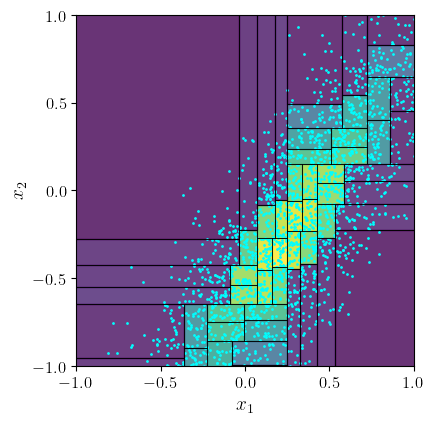

In [10]:
K = 2500
plot_2dtree(leaves, sig[:K].T)

## Exercises
**Note**: The 2D tensor of points $X$ and their associated labels $Y$ were generated earlier. Remember, $X$ includes points from both signal and background.


 1. Using the trained classifier, compute $D(x)$ for *all* points $x \in X$. These values will be the weights $w(x)$, one for each point. Note that the shape of the tensor returned by the model is (n, 1), where n is the number of points. Therefore, you will need to `squeeze()` away dimension 1:
    ```python
        D = model(X).squeeze()
    ``` 
    to change the shape from (n, 1) to (n, ), that is, to a 1D tensor. For simplicity, to avoid type conflicts, I recommend changing *all* PyTorch tensors to numpy arrays, e.g.:
    ```python
        x = X.detach().cpu().numpy()
        y = Y.detach().cpu().numpy()
        w = D.detach().cpu().numpy()
    ```
 3. From the `leaves` object, create a numpy array `s` of the probability densities of the signal.
 4. Using the method `find_leaf(x)` of object KDTree object `tree` (which returns the leaf into which the point $x$ falls) create a numpy array $W$ of length `len(leaves)` in which each bin contains the summed weights of all points $x \in X$ that fall in that leaf. (*Hint*: to create a numpy array of length `len(leaves)`, initialized to zero, do `W = np.zeros(len(leaves))`.) A leaf is identified by its leaf identifier, the attribute, ID. Identifiers go from 0 for the leaf with the highest density to len(leaves)-1 for the leaf with the lowest density.
 5. Normalize $W$ so that the latter contains probability densities. (See Introduction for how this is done for the signal densities.) 
 6. Create a plot that compares the two arrays of densities.


Feel free to consult your favorite AI agent for a statistical procedure to test whether the two arrays of densities are the same within statistical uncertainties. How would you account for the fact that there are statistical uncertainties in all the estimated densities?

In [11]:
sig.shape, X.shape, Y.shape

((262144, 2), torch.Size([200000, 2]), torch.Size([200000, 1]))

In [12]:
leaf = tree.find_leaf(X[0])
leaf.ID, leaf.density, leaf.volume, leaf.bounds

(50,
 0.05016584247925556,
 0.3114669111051251,
 array([[-0.22627322, -0.07688157],
        [-3.12361872, -1.038717  ]]))